# Data grouping and gridding for LEO satellite data

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pathlib

import geospacelab.visualization.mpl.dashboards as dashboards

Create a new figure: Figure(1000x1000).


Load IGRF coefficients ...


Searching the data product "DNS_POD" with the version "latest" on the server...
INFO: Indexing the files for the product DNS_POD of the satellite A ...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240510T000000_20240510T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240511T000000_20240511T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240512T000000_20240512T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240513T000000_20240513T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/S

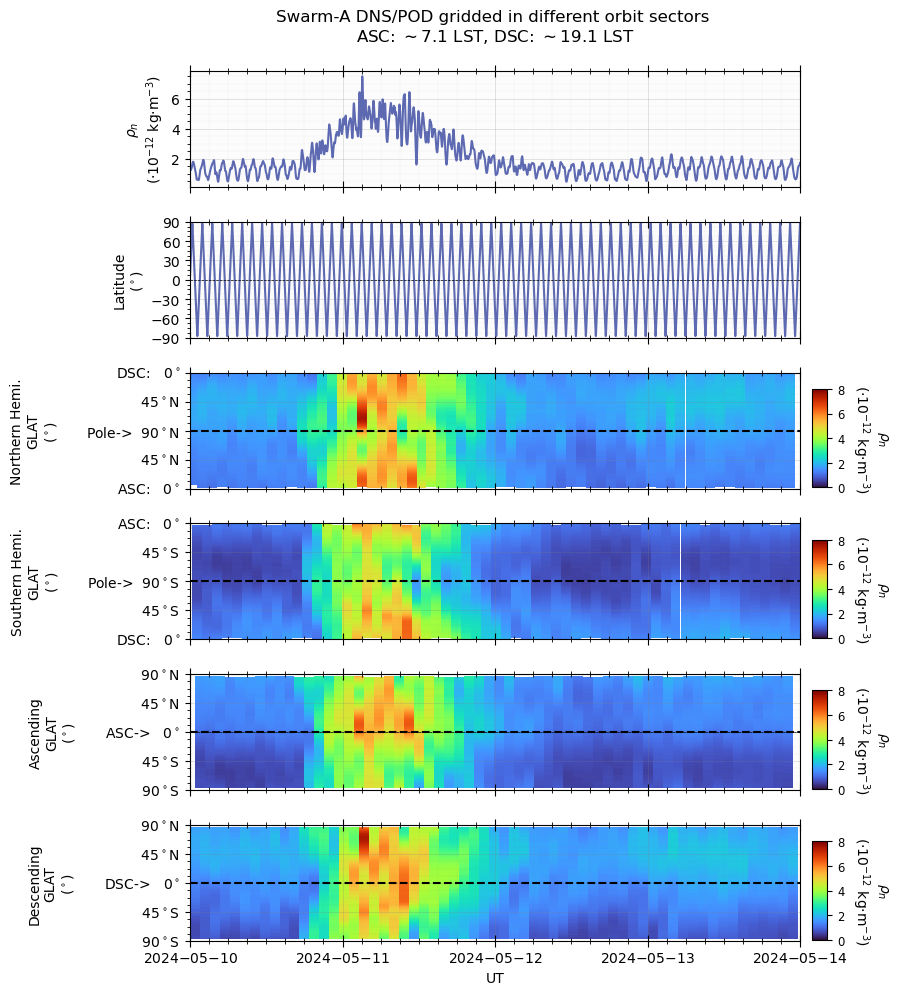

In [2]:

def test_gridding_interpolation_DNS_POD():
    """Test Swarm DNS/POD data product
    
    """
    dt_fr = datetime.datetime(2024, 5, 10, 0, 0)
    dt_to = datetime.datetime(2024, 5, 14, 0, 0)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (10, 10)},
        )

    ds = db.dock(datasource_contents=['esa_eo', 'swarm', 'l2daily', 'dns_pod'], sat_id='A', add_APEX=True, add_AACGM=True)
    
    ds_sector_N = ds.gridding(
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        sector = 'N',
        sector_cs = 'GEO',
        boundary_lat = 0.,
        along_track_interp=True, along_track_interp_method='linear',
        x_grid_res=None,
        y_grid_res=0.5,
        x_data_res=None, 
        y_data_res=30, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    ds_sector_S = ds.gridding(
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        sector = 'S',
        sector_cs = 'GEO',
        boundary_lat = 0.,
        along_track_interp=True, along_track_interp_method='linear',
        x_grid_res=None,
        y_grid_res=0.5,
        x_data_res=None, 
        y_data_res=30, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    ds_sector_ASC = ds.gridding(
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        sector = 'ASC',
        sector_cs = 'GEO',
        boundary_lat = 90.,
        along_track_interp=True, along_track_interp_method='linear',
        x_grid_res=None,
        y_grid_res=0.5,
        x_data_res=None, 
        y_data_res=30, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    ds_sector_DSC = ds.gridding(
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        sector = 'DSC',
        sector_cs = 'GEO',
        boundary_lat = 90.,
        along_track_interp=True, along_track_interp_method='linear',
        x_grid_res=None,
        y_grid_res=0.5,
        x_data_res=None, 
        y_data_res=30, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    grid_rho_n_N = ds_sector_N['SECTOR_N_GRID_rho_n']
    grid_rho_n_S = ds_sector_S['SECTOR_S_GRID_rho_n']
    grid_rho_n_ASC = ds_sector_ASC['SECTOR_ASC_GRID_rho_n']
    grid_rho_n_DSC = ds_sector_DSC['SECTOR_DSC_GRID_rho_n']
    
    panel_layouts = [
        [ds['rho_n']],
        [ds['SC_GEO_LAT']],
        # [ds['SC_GEO_LON']],
        # [ds['SC_GEO_LST']],
        [grid_rho_n_N],
        [grid_rho_n_S],
        [grid_rho_n_ASC],
        [grid_rho_n_DSC],
    ]
    
    # set axis scale and unit for better visualization, removing exponent for density in the upper-left corner of the panel.
    ds['rho_n'].visual.axis[1].data_scale = 1e12 
    ds['rho_n'].visual.axis[1].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    
    grid_rho_n_N.visual.axis[2].data_scale = 1e12
    grid_rho_n_N.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    grid_rho_n_S.visual.axis[2].data_scale = 1e12
    grid_rho_n_S.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    grid_rho_n_ASC.visual.axis[2].data_scale = 1e12
    grid_rho_n_ASC.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    grid_rho_n_DSC.visual.axis[2].data_scale = 1e12
    grid_rho_n_DSC.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    
    # Set sector labels and data limits
    grid_rho_n_N.visual.axis[2].lim = [0, 8]
    grid_rho_n_S.visual.axis[2].lim = [0, 8]
    grid_rho_n_ASC.visual.axis[2].lim = [0, 8]
    grid_rho_n_DSC.visual.axis[2].lim = [0, 8]
    
    db.set_layout(panel_layouts=panel_layouts, left=0.25, right=0.86, top=0.93, bottom=0.06, hspace=0.3)
    db.draw()
    
    # Post-settings
    # Set panel and axis labels for sector panels
    # For Sector North panel
    ax = db.panels[2]()
    ds_sector_N.format_pseudo_lat_axis(ax, 'N', inverse=False, add_sperator=True)
    ds_sector_N.format_pseudo_lat_label(ax, 'N', y_tick_res=45)
    ax.set_ylabel('Northern Hemi.\n' + ax.get_ylabel(), labelpad=20)
    ax = db.panels[3]()
    ds_sector_S.format_pseudo_lat_axis(ax, 'S', inverse=False, add_sperator=True)
    ds_sector_S.format_pseudo_lat_label(ax, 'S', y_tick_res=45)
    ax.set_ylabel('Southern Hemi.\n' + ax.get_ylabel(), labelpad=20)
    ax = db.panels[4]()
    ds_sector_ASC.format_pseudo_lat_axis(ax, 'ASC', inverse=False, add_sperator=True)
    ds_sector_ASC.format_pseudo_lat_label(ax, 'ASC', y_tick_res=45)
    ax.set_ylabel('Ascending\n' + ax.get_ylabel(), labelpad=20)
    ax = db.panels[5]()
    ds_sector_DSC.format_pseudo_lat_axis(ax, 'DSC', inverse=True, add_sperator=True)
    ds_sector_DSC.format_pseudo_lat_label(ax, 'DSC', y_tick_res=45)
    ax.set_ylabel('Descending\n' + ax.get_ylabel(), labelpad=20)
    
    lsts_asc = ds_sector_N.ascending_nodes['GEO_LST']
    lsts_dsc = ds_sector_N.descending_nodes['GEO_LST']
    lst_median_asc = lsts_asc[len(lsts_asc) // 2]
    lst_median_dsc = lsts_dsc[len(lsts_dsc) // 2]
    
    db.add_title(
        y=1.03,
        title='Swarm-{} DNS/POD gridded in different orbit sectors \n'.format(ds.sat_id) + \
            r'ASC: $\sim${:.1f} LST, DSC: $\sim${:.1f} LST'.format(lst_median_asc, lst_median_dsc),
        fontsize='large', append_time=False)
    
    return db
db = test_gridding_interpolation_DNS_POD()
db.show()

Create a new figure: Figure(1000x1000).
Searching the data product "FAC_TMS" with the version "latest" on the server...
INFO: Indexing the files for the product FAC_TMS of the satellite A ...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240510T000000_20240510T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240511T000000_20240511T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240512T000000_20240512T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240513T000000_20240513T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/d

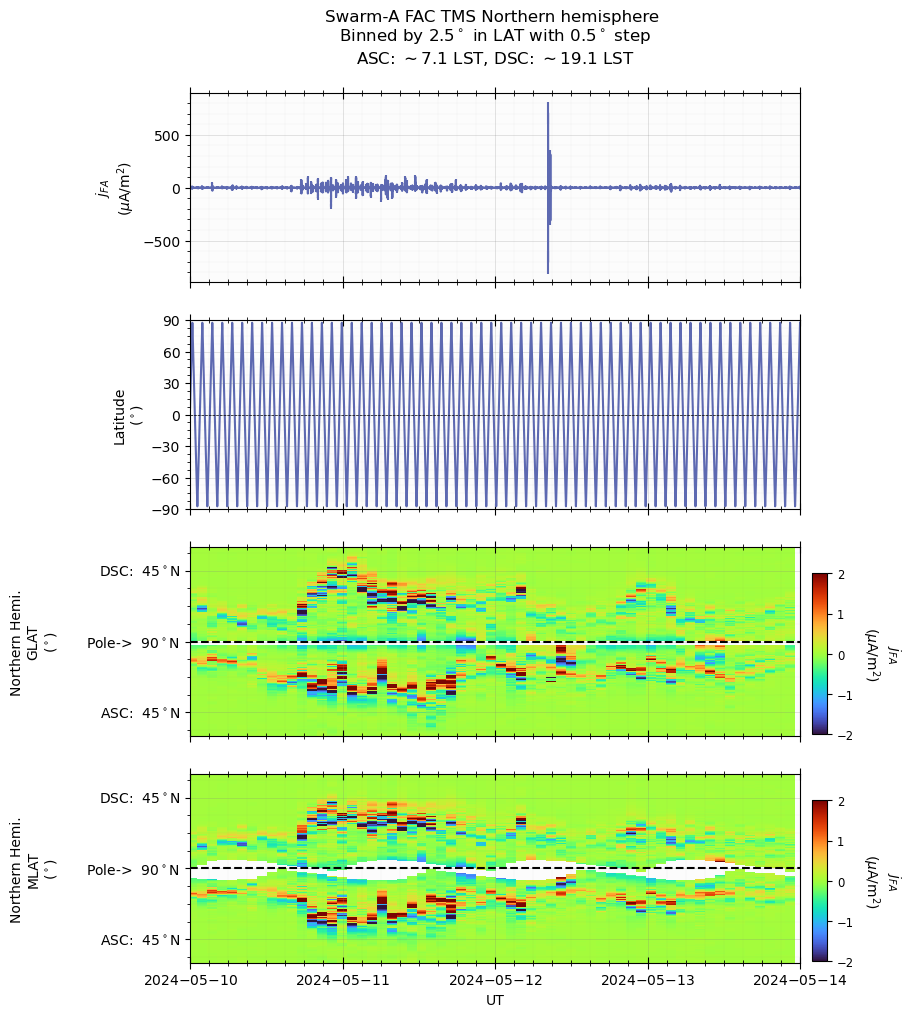

In [3]:

    
def test_gridding_binning_FAC_TMS():
    """Test Swarm FAC TMS data product
    
    """
    dt_fr = datetime.datetime(2024, 5, 10, 0, 0)
    dt_to = datetime.datetime(2024, 5, 14, 0, 0)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (10, 10)},
    )

    # ds_tms_dual = db.dock(datasource_contents=['esa_eo', 'swarm', 'l2daily', 'fac_tms_dual'], add_APEX=True,)
    
    ds_tms = db.dock(datasource_contents=['esa_eo', 'swarm', 'l2daily', 'fac_tms'], sat_id='A', add_APEX=True,)
    # ds_tms_C = db.dock(datasource_contents=['esa_eo', 'swarm', 'l2daily', 'fac_tms'], sat_id='C', add_APEX=True,)

    ds_sector_N = ds_tms.gridding(
        var_names_gridding=['j_FA',],
        sector = 'N',
        sector_cs = 'GEO',
        boundary_lat = 30.,
        along_track_binning=True, along_track_interp=False,
        along_track_binning_method='mean',
        along_track_binning_step=0.5,
        along_track_binning_res=2.5,
        x_grid_res=None,
        y_grid_res=2,
        x_data_res=None, 
        y_data_res=1, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    ds_sector_N_APEX = ds_tms.gridding(
        var_names_gridding=['j_FA',],
        sector = 'N',
        sector_cs = 'APEX',
        boundary_lat = 30.,
        along_track_binning=True, along_track_interp=False,
        along_track_binning_method='mean',
        along_track_binning_step=0.5,
        along_track_binning_res=2.5,
        x_grid_res=None,
        y_grid_res=2,
        x_data_res=None, 
        y_data_res=1, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    j_FA_N = ds_sector_N['SECTOR_N_GRID_j_FA']
    j_FA_N_APEX = ds_sector_N_APEX['SECTOR_N_GRID_j_FA']
    
    panel_layouts = [
        [ds_tms['j_FA']],
        [ds_tms['SC_GEO_LAT']],
        [j_FA_N,],
        [j_FA_N_APEX,],
    ]
    
    j_FA_N.visual.axis[2].lim = [-2, 2]
    j_FA_N_APEX.visual.axis[2].lim = [-2, 2]
    

    db.set_layout(panel_layouts=panel_layouts, left=0.25, right=0.86, top=0.93, bottom=0.06, hspace=0.2)
    db.draw()
    
    ax = db.panels[2]()
    ds_sector_N.format_pseudo_lat_axis(ax, 'N', inverse=False, add_sperator=True)
    ds_sector_N.format_pseudo_lat_label(ax, 'N', y_tick_res=45)
    ax.set_ylabel('Northern Hemi.\n' + ax.get_ylabel(), labelpad=20)
    ax = db.panels[3]()
    ds_sector_N_APEX.format_pseudo_lat_axis(ax, 'N', inverse=False, add_sperator=True)
    ds_sector_N_APEX.format_pseudo_lat_label(ax, 'N', y_tick_res=45)
    ax.set_ylabel('Northern Hemi.\n' + ax.get_ylabel(), labelpad=20)
    
    lsts_asc = ds_sector_N.ascending_nodes['GEO_LST']
    lsts_dsc = ds_sector_N.descending_nodes['GEO_LST']
    lst_median_asc = lsts_asc[len(lsts_asc) // 2]
    lst_median_dsc = lsts_dsc[len(lsts_dsc) // 2]
    
    db.add_title(
        y=1.03,
        title='Swarm-{} FAC TMS Northern hemisphere \n'.format(ds_tms.sat_id) + \
        r'Binned by 2.5$^\circ$ in LAT with 0.5$^\circ$ step' + '\n' + \
        r'ASC: $\sim${:.1f} LST, DSC: $\sim${:.1f} LST'.format(lst_median_asc, lst_median_dsc),
        fontsize='large', append_time=False)
    
    return db
db = test_gridding_binning_FAC_TMS()
db.show()